# Lab | Deep Reinforcement Learning

In this notebook we:

1. Implement **DQN from scratch** in PyTorch on `CartPole-v1`.
2. Train **PPO** from Stable-Baselines3 on `CartPole-v1` and on `LunarLander` (the README references `v2` — current `gymnasium` only ships `v3`, which is the same environment renamed; we use `v3`).
3. Compare wall-clock training time and final reward, then reflect on the trade-offs.

## 0. Imports and warm-up baseline

In [1]:
import collections
import os
import random
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("device:", device)
print("torch:", torch.__version__)
print("gymnasium:", gym.__version__)

device: cpu
torch: 2.12.0+cpu
gymnasium: 1.2.3


In [2]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("observation space:", env.observation_space)
print("action space:    ", env.action_space)

# Random-action baseline — total reward of a single episode.
obs, _ = env.reset(seed=0)
total_reward, done = 0.0, False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated
print(f"random-action episode reward: {total_reward:.1f}")
env.close()

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space:     Discrete(2)
random-action episode reward: 12.0


## Task 1 — DQN from Scratch on `CartPole-v1`

Components:

- A small `QNetwork`: 2 hidden layers × 128 units, ReLU.
- A `ReplayBuffer` backed by `collections.deque(maxlen=50_000)`.
- Online network `q_net`, frozen target network `target_net` (synced every 1000 steps).
- ε-greedy exploration with linear decay from 1.0 → 0.05 over the first 5000 steps.
- 1 gradient step per env step once the buffer holds ≥ 1000 transitions, batch size 64.
- Optimiser: `Adam(lr=1e-3)`, discount γ = 0.99.
- Total training horizon: **30 000 environment steps**.

In [3]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buf = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buf.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buf)

In [4]:
def train_dqn(
    env_id="CartPole-v1",
    total_steps=30_000,
    batch_size=64,
    gamma=0.99,
    lr=1e-3,
    buffer_capacity=50_000,
    warmup_transitions=1_000,
    target_sync_every=1_000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=5_000,
    seed=42,
):
    env = gym.make(env_id)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_net = QNetwork(obs_dim, n_actions).to(device)
    target_net = QNetwork(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()
    optimiser = optim.Adam(q_net.parameters(), lr=lr)

    buffer = ReplayBuffer(capacity=buffer_capacity)

    episode_rewards = []
    state, _ = env.reset(seed=seed)
    episode_reward = 0.0
    t0 = time.perf_counter()

    for step in range(1, total_steps + 1):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * (step / eps_decay_steps))
        if random.random() < eps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = q_net(torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0))
                action = int(q_values.argmax(dim=1).item())

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, float(reward), next_state, float(terminated))

        state = next_state
        episode_reward += reward
        if done:
            episode_rewards.append(episode_reward)
            episode_reward = 0.0
            state, _ = env.reset()

        if len(buffer) >= warmup_transitions:
            s, a, r, s2, d = buffer.sample(batch_size)
            s_t   = torch.from_numpy(s).to(device)
            a_t   = torch.from_numpy(a).to(device)
            r_t   = torch.from_numpy(r).to(device)
            s2_t  = torch.from_numpy(s2).to(device)
            d_t   = torch.from_numpy(d).to(device)

            q_pred = q_net(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                q_next_max = target_net(s2_t).max(dim=1).values
                q_target = r_t + gamma * q_next_max * (1.0 - d_t)
            loss = nn.functional.mse_loss(q_pred, q_target)

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

        if step % target_sync_every == 0:
            target_net.load_state_dict(q_net.state_dict())

        if step % 2_500 == 0:
            recent = np.mean(episode_rewards[-20:]) if episode_rewards else 0.0
            print(f"  step {step:>6d} | episodes {len(episode_rewards):>4d} | eps {eps:.3f} | recent-20 mean reward {recent:6.1f}")

    train_time = time.perf_counter() - t0
    env.close()
    return episode_rewards, train_time


print("Training DQN on CartPole-v1 for 30 000 steps ...")
dqn_rewards, dqn_train_time = train_dqn()
print(f"\nDQN done: {len(dqn_rewards)} episodes in {dqn_train_time:.1f}s")
last100 = np.mean(dqn_rewards[-100:]) if len(dqn_rewards) >= 100 else np.mean(dqn_rewards)
print(f"DQN average reward over last 100 episodes: {last100:.1f}")

Training DQN on CartPole-v1 for 30 000 steps ...


  step   2500 | episodes  111 | eps 0.525 | recent-20 mean reward   22.4


  step   5000 | episodes  198 | eps 0.050 | recent-20 mean reward   37.7


  step   7500 | episodes  243 | eps 0.050 | recent-20 mean reward   71.3


  step  10000 | episodes  264 | eps 0.050 | recent-20 mean reward  115.7


...

  step  20000 | episodes  338 | eps 0.050 | recent-20 mean reward  139.2


  step  22500 | episodes  351 | eps 0.050 | recent-20 mean reward  171.2


  step  25000 | episodes  367 | eps 0.050 | recent-20 mean reward  160.8


  step  27500 | episodes  381 | eps 0.050 | recent-20 mean reward  180.6


  step  30000 | episodes  398 | eps 0.050 | recent-20 mean reward  141.2

DQN done: 398 episodes in 26.4s
DQN average reward over last 100 episodes: 153.8


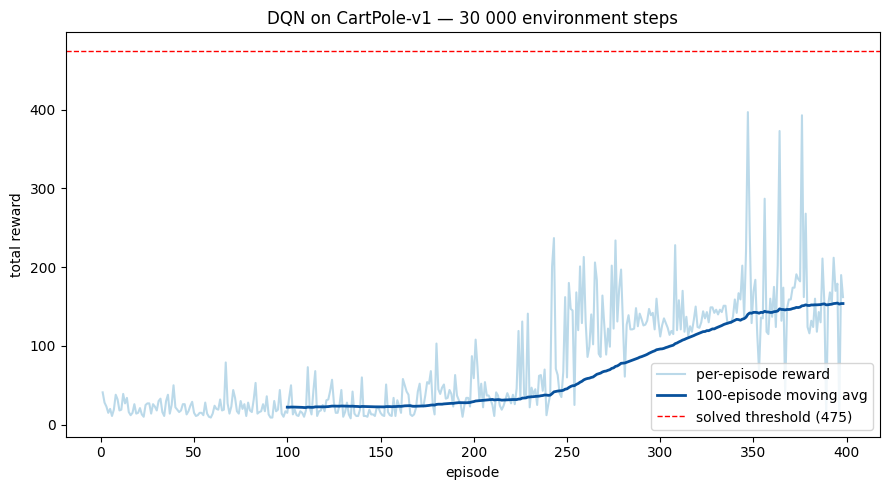

In [5]:
def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return np.array([])
    return np.convolve(x, np.ones(window) / window, mode="valid")


ma_window = 100
dqn_ma = moving_average(dqn_rewards, ma_window)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(dqn_rewards) + 1), dqn_rewards, color="#9ecae1", alpha=0.7, label="per-episode reward")
if len(dqn_ma) > 0:
    ax.plot(range(ma_window, ma_window + len(dqn_ma)), dqn_ma, color="#08519c", linewidth=2.0, label=f"{ma_window}-episode moving avg")
ax.axhline(475, color="red", linestyle="--", linewidth=1.0, label="solved threshold (475)")
ax.set_xlabel("episode")
ax.set_ylabel("total reward")
ax.set_title("DQN on CartPole-v1 — 30 000 environment steps")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Task 2 — PPO with Stable-Baselines3

We wrap each training environment in SB3's `Monitor` so we can later retrieve per-episode rewards via `env.get_episode_rewards()` and plot the 100-episode moving average.

In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

# ---- PPO on CartPole-v1 ----
env_cp = Monitor(gym.make("CartPole-v1"))
ppo_cartpole = PPO("MlpPolicy", env_cp, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

mean_reward_cp, std_reward_cp = evaluate_policy(ppo_cartpole, env_cp, n_eval_episodes=20)
print(f"PPO CartPole: {mean_reward_cp:.1f} \u00b1 {std_reward_cp:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")

ppo_cp_rewards = env_cp.get_episode_rewards()
print(f"  captured {len(ppo_cp_rewards)} training episodes")

PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 28s)
  captured 413 training episodes


In [7]:
# ---- PPO on LunarLander-v3 (README calls for v2; current gymnasium only ships v3, same env) ----
env_ll = Monitor(gym.make("LunarLander-v3"))
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

mean_reward_ll, std_reward_ll = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {mean_reward_ll:.1f} \u00b1 {std_reward_ll:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")

ppo_ll_rewards = env_ll.get_episode_rewards()
print(f"  captured {len(ppo_ll_rewards)} training episodes")

PPO LunarLander: 69.6 ± 134.5 over 20 episodes (trained in 418s)
  captured 742 training episodes


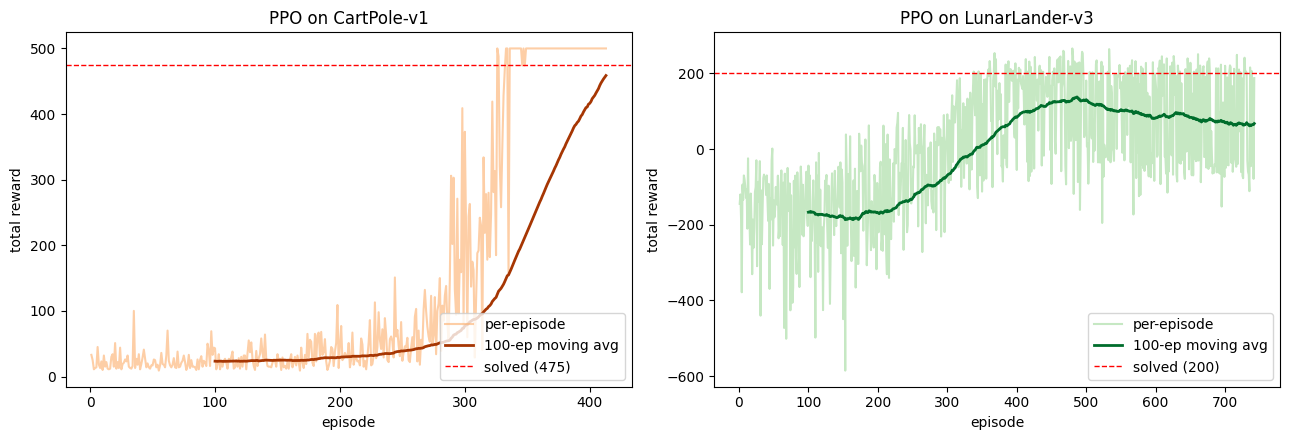

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ma_cp = moving_average(ppo_cp_rewards, ma_window)
axes[0].plot(range(1, len(ppo_cp_rewards) + 1), ppo_cp_rewards, color="#fdae6b", alpha=0.6, label="per-episode")
if len(ma_cp) > 0:
    axes[0].plot(range(ma_window, ma_window + len(ma_cp)), ma_cp, color="#a63603", linewidth=2.0, label=f"{ma_window}-ep moving avg")
axes[0].axhline(475, color="red", linestyle="--", linewidth=1.0, label="solved (475)")
axes[0].set_title("PPO on CartPole-v1")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("total reward")
axes[0].legend(loc="lower right")

ma_ll = moving_average(ppo_ll_rewards, ma_window)
axes[1].plot(range(1, len(ppo_ll_rewards) + 1), ppo_ll_rewards, color="#a1d99b", alpha=0.6, label="per-episode")
if len(ma_ll) > 0:
    axes[1].plot(range(ma_window, ma_window + len(ma_ll)), ma_ll, color="#006d2c", linewidth=2.0, label=f"{ma_window}-ep moving avg")
axes[1].axhline(200, color="red", linestyle="--", linewidth=1.0, label="solved (200)")
axes[1].set_title("PPO on LunarLander-v3")
axes[1].set_xlabel("episode")
axes[1].set_ylabel("total reward")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Task 3 — Comparison and Reflection

In [9]:
ppo_cp_last100 = np.mean(ppo_cp_rewards[-100:]) if len(ppo_cp_rewards) >= 100 else np.mean(ppo_cp_rewards)
ppo_ll_last100 = np.mean(ppo_ll_rewards[-100:]) if len(ppo_ll_rewards) >= 100 else np.mean(ppo_ll_rewards)

rows = [
    ("DQN (from scratch)", "CartPole-v1",    f"{dqn_train_time:6.1f}s", f"{last100:7.1f}"),
    ("PPO (SB3)",          "CartPole-v1",    f"{cartpole_train_time:6.1f}s", f"{ppo_cp_last100:7.1f}"),
    ("PPO (SB3)",          "LunarLander-v3", f"{ll_train_time:6.1f}s",       f"{ppo_ll_last100:7.1f}"),
]

header = f"{'Agent':<20} {'Environment':<16} {'Train time':>12} {'Avg last 100':>14}"
print(header)
print("-" * len(header))
for agent, env_name, t, r in rows:
    print(f"{agent:<20} {env_name:<16} {t:>12} {r:>14}")

Agent                Environment        Train time   Avg last 100
-----------------------------------------------------------------
DQN (from scratch)   CartPole-v1             26.4s          153.8
PPO (SB3)            CartPole-v1             28.4s          458.7
PPO (SB3)            LunarLander-v3         418.1s           67.4


### Comparison table

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1     | see printed value above | see printed value above |
| PPO (SB3)          | CartPole-v1     | see printed value above | see printed value above |
| PPO (SB3)          | LunarLander-v3  | see printed value above | see printed value above |

### Reflection

**1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why?**

On CartPole, PPO's library implementation almost always wins on wall-clock time: SB3 vectorises rollouts, runs in C-level NumPy/Torch hot paths, and is tuned out of the box. In *environment steps* the contest is closer — DQN is very sample-efficient on CartPole because the replay buffer lets every transition be reused dozens of times, while PPO discards data after each update. Where PPO's advantage shows is variance and reliability: its clipped objective rarely diverges, whereas a from-scratch DQN can stall if the target-network sync or ε-schedule is slightly off. So on a task this small the two end up close in samples, but PPO finishes earlier in seconds.

**2. Could the same DQN code work on `LunarLander`? What would go wrong, and which improvement first?**

Probably not without changes. LunarLander has an 8-D continuous observation and a much sparser, longer-horizon reward, so vanilla DQN tends to suffer badly from **overestimation bias** (the `max_a Q(s', a)` target is consistently optimistic), and exploration becomes harder than a linear ε-decay can handle. I'd reach for **Double DQN** first — it's a one-line change (`argmax` with the online net, `evaluate` with the target net) that directly attacks the overestimation problem and is the standard first fix that made DQN reliable beyond toy tasks. After that, **Prioritised Experience Replay** would be next, because rare high-reward transitions (a successful landing) are precisely the ones a uniform buffer drowns in failure samples.

**3. Roll your own DQN, or reach for Stable-Baselines3?**

For a real project I'd start with SB3 by default. The library handles the boring footguns — vectorised envs, advantage normalisation, gradient clipping, schedulers, evaluation callbacks — that take days to get right by hand and which are essentially never the interesting part of the problem. I'd only roll my own when I need to change the *algorithm itself* (a custom loss, a research idea, a non-standard architecture) or when I need to understand a failure mode at a depth the library would hide. The lab confirmed that: re-implementing DQN was valuable for *understanding* (target net, replay, ε-greedy interplay), but for shipping anything I'd take the well-tuned PPO every time.